In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sparse
import trimesh
from tqdm import tqdm

In [2]:

np_file_dir = Path('data')
np_filename = 'job_14965616_99_sparse_5d_srm.npz'
np_file_path = np_file_dir / np_filename
np_data = np.load(np_file_path)
for obj in np_data.keys():
    print(obj, np_data[obj].shape)
hist_bins = np_data['hist_bins']
hist_range = np_data['hist_range']

coords (6879691, 5)
counts (6879691,)
hist_bins (1,)
hist_range (2,)
energy_min (1,)
energy_max (1,)
file_count (1,)
total_events (1,)
total_sim_time (1,)
processed_root_members (1,)
job_tag (1,)
accumulated_counts (1,)


In [4]:
all_coords = []
all_counts = []
for batch_id in tqdm(range(100)):
    np_filename = f'job_14965616_{batch_id}_sparse_5d_srm.npz'
    np_data = np.load(np_file_dir / np_filename)
    coords = np_data['coords']
    coords[:, 0] = coords[:, 0] - 1
    all_coords.append(coords)
    all_counts.append(np_data['counts'].reshape(-1, 1))

stacked_coords = np.vstack(all_coords)
stacked_counts = np.vstack(all_counts)

print(stacked_coords.shape, stacked_counts.shape)


100%|██████████| 100/100 [01:23<00:00,  1.19it/s]


(1218520130, 5) (1218520130, 1)


In [6]:

sparse_srm_shape = (80,625, int(hist_bins[0]), int(hist_bins[0]), int(hist_bins[0]))
print("sparse_srm_shape:", sparse_srm_shape)

global_srm = sparse.COO(
    stacked_coords.T, 
    stacked_counts.flatten(), 
    shape=sparse_srm_shape, 
    has_duplicates=True # This does the actual accumulation
)

sparse_srm_shape: (80, 625, 80, 80, 80)


In [9]:
del stacked_coords, stacked_counts

In [8]:
import h5py

file_list_strs = [str(p) for p in list(np_file_dir.glob('job_14965616_*_sparse_5d_srm.npz'))]
output_h5_file = np_file_dir / 'job_14965616_stacked_sparse_5d_srm.h5'
print(f"Saving to {output_h5_file}...")

with h5py.File(output_h5_file, 'w') as f:
    # --- A. Save the AGGREGATED Sparse Array ---
    # Create a clean folder inside the HDF5 file just for the matrix
    srm_group = f.create_group('srm')
    
    # Save the internal arrays of the newly aggregated global_srm
    # Using gzip compression will massively shrink the file size
    srm_group.create_dataset('coords', data=global_srm.coords, compression='gzip')
    srm_group.create_dataset('data', data=global_srm.data, compression='gzip')
    srm_group.attrs['shape'] = global_srm.shape  # Store shape as metadata
    
    # --- B. Save the Dense Arrays & Metadata ---
    f.create_dataset('hist_bins', data=hist_bins)
    f.create_dataset('hist_range', data=hist_range)
    
    # Strings in HDF5 require a specific variable-length string dtype
    str_dtype = h5py.string_dtype(encoding='utf-8')
    f.create_dataset('processed_files', data=file_list_strs, dtype=str_dtype)

print("Saved successfully.")

Saving to data/job_14965616_stacked_sparse_5d_srm.h5...
Saved successfully.


In [8]:
# Read coords, counts, hist_bins, hist_range
coords = np_data['coords']
counts = np_data['counts']
hist_bins = np_data['hist_bins']
hist_range = np_data['hist_range']
print(np_data['file_count'])
print(np_data['job_tag'])
print(np_data['accumulated_counts'])
print(np_data['total_events'])
print(counts.sum()/ np_data['total_events'][0])

[55]
['job_14965616_99']
[7067133]
[27500046279]
0.00025698622207035013


Text(0, 0.5, 'Y-axis')

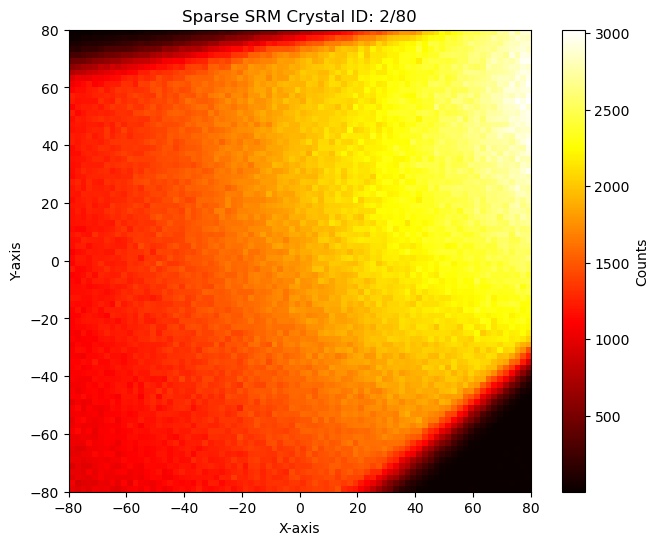

In [10]:
# plot sparse_srm_crystal
plt.ion()
plt.figure(figsize=(8, 6))
crystal_id = 1  # Change this to visualize different crystals
plt.imshow(global_srm[crystal_id].sum(axis=(0,3)).todense().T, cmap='hot', interpolation='none', extent=(-80, 80, -80, 80), origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Sparse SRM Crystal ID: {crystal_id+1}/80')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

In [11]:
import qmirt

meshes =  qmirt.plot.wrl.parse_vrml_indexed_face_sets(Path("../scanner_and_phantom_geometry.wrl"))
print(f"Loaded {len(meshes)} meshes from VRML file.")
# print(meshes[0])  # Print the first mesh for inspection
this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == "DetectorCrystal_1:0"), None)

Loaded 347 meshes from VRML file.


In [12]:
def triangulate_polygons(polygons):
    triangles = []
    for polygon in polygons:
        if len(polygon) < 3:
            continue  # Not enough vertices to form a triangle

        # Triangulate the polygon using a fan triangulation method
        for i in range(1, len(polygon) - 1):
            triangles.append([polygon[0], polygon[i], polygon[i + 1]])

    return np.array(triangles)

def add_mesh_sharp_edges(axs, mesh):
    # 1. Find the "sharp" edges to hide flat diagonals
    # face_adjacency_angles gives the angle (in radians) between adjacent triangles.
    # We use > 0.1 radians (~5 degrees) to catch true geometric corners.
    is_sharp = mesh.face_adjacency_angles > 0.1

    # Extract the (N, 2) array of vertex indices that form these sharp edges
    sharp_edges = mesh.face_adjacency_edges[is_sharp]

    v = mesh.vertices

    # Helper function to plot just the sharp line segments in 2D
    def draw_wireframe(ax, coords_2d):
        for edge in sharp_edges:
            # Get the 2D coordinates for the start and end of the edge
            p1 = coords_2d[edge[0]]
            p2 = coords_2d[edge[1]]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="red", linewidth=1.5)

    # 1. XY Projection (Drop Z)
    draw_wireframe(axs[0], v[:, [0, 1]])

    # 2. XZ Projection (Drop Y)
    draw_wireframe(axs[1], v[:, [0, 2]])

    # 3. YZ Projection (Drop X)
    draw_wireframe(axs[2], v[:, [1, 2]])


def plot_sparse_3d_projections(
    srm_crystal_sparse, id=1, *, prefix:str = "Crystal", fov_size_mm=(100, 100, 100)
):

    # Calculate the projections
    projections = [srm_crystal_sparse.sum(axis=2-i).todense() for i in range(3)]
    extent_indices = [(0, 1), (0, 2), (1, 2)]
    extents = [
        (-fov_size_mm[extent_indices[i][0]] * 0.5, fov_size_mm[extent_indices[i][0]] * 0.5, -fov_size_mm[extent_indices[i][1]] * 0.5, fov_size_mm[extent_indices[i][1]] * 0.5) for i in range(3)
    ]
    axes_titles = ["XY Projection", "XZ Projection", "YZ Projection"]
    axis_labels = [("X-axis", "Y-axis"), ("X-axis", "Z-axis"), ("Y-axis", "Z-axis")]

    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))

    for i in range(3):
        ax = axs[i]
        im = ax.imshow(projections[i].T, cmap="hot", interpolation="none", extent=extents[i], origin="lower")
        ax.set_title(f"{axes_titles[i]} ({prefix} {id})")
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_aspect("equal")
        ax.set_xlim(-400, 400)
        ax.set_ylim(-400, 400)

    axs[2].set_title(f"YZ Projection ({prefix} {id})")
    axs[2].set_xlabel("Y-axis")
    axs[2].set_ylabel("Z-axis")

    fig.colorbar(axs[0].images[0], ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    return fig, axs

Processing Head ID 1, Row ID 0


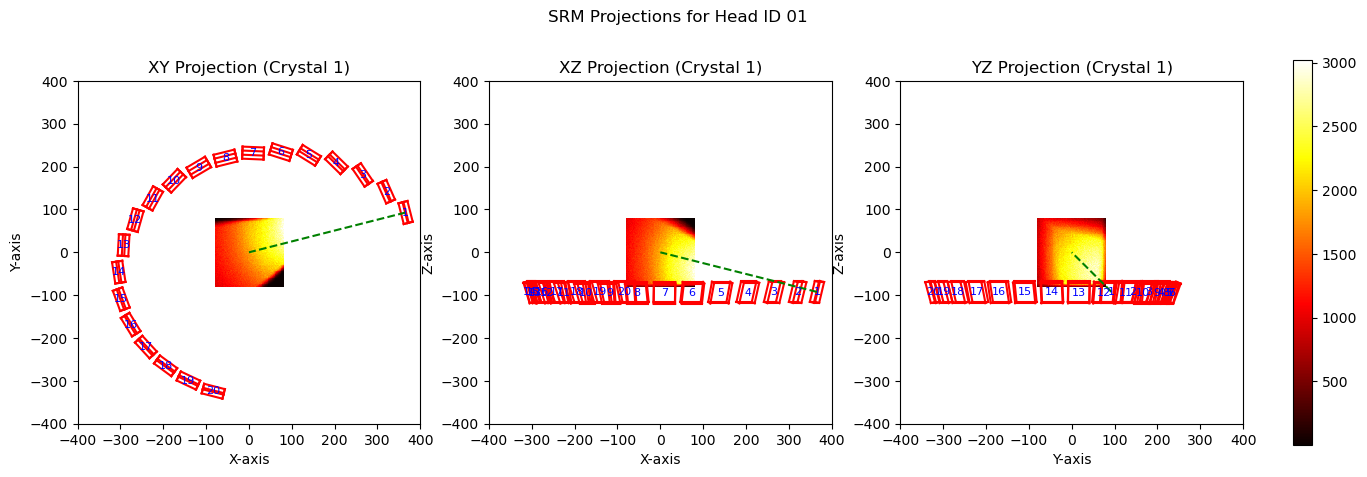

In [20]:
plt.ion()
for head_id in range(1):
    fig, axs = plot_sparse_3d_projections(
        global_srm[crystal_id].sum(axis=0), id=head_id+1, fov_size_mm=(160, 160, 160)
    )

    centers = []
    head_row_id = head_id // 20
    print(f"Processing Head ID {head_id+1}, Row ID {head_row_id}")
    for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
        this_crystal_mesh = next(
            (
                mesh
                for mesh in meshes
                if mesh["name"] == f"DetectorCrystal_{crysta_id}:0"
            ),
            None,
        )
        if this_crystal_mesh is None:
            print(f"Warning: Could not find mesh for DetectorCrystal_{crysta_id}:0")
            continue
        vertices = this_crystal_mesh["vertices"]
        polygons = this_crystal_mesh["polygons"]
        # Convert the parsed polygons into an (m, 3) triangle array
        faces_array = triangulate_polygons(polygons)
        crystal_mesh = trimesh.Trimesh(
            vertices=vertices,
            faces=faces_array,
            process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
        )

        add_mesh_sharp_edges(axs, crystal_mesh)
        axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
        center = crystal_mesh.centroid
        centers.append(center)
        
        for axs_id in range(3):
            axs[axs_id].text(
                center[axes_xyz_id[axs_id][0]],
                center[axes_xyz_id[axs_id][1]],
                f"{crysta_id}",
                color="blue",
                fontsize=8,
                ha="center",
                va="center",
            )

    # principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)
    principal_axes = np.stack([centers[head_id],np.array([0,0,0])],axis=0)
    for axs_id in range(3):
        axs[axs_id].plot(
                principal_axes[:, axes_xyz_id[axs_id][0]],
                principal_axes[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
        )
        

    fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
    plt.show()
    plt.close(fig)  # Close the figure to free up memory

In [22]:
plt.ioff()  # Turn off interactive mode to prevent figures from displaying in some environments
output_dir = Path("plots_OSPool_GATE10_MC_SRM")
output_dir.mkdir(parents=True, exist_ok=True)

for head_id in range(80):
    fig, axs = plot_sparse_3d_projections(
        global_srm[head_id].sum(axis=0), id=head_id+1, fov_size_mm=(160, 160, 160)
    )

    centers = []
    head_row_id = head_id // 20
    print(f"Processing Head ID {head_id+1}, Row ID {head_row_id}")
    for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
        this_crystal_mesh = next(
            (
                mesh
                for mesh in meshes
                if mesh["name"] == f"DetectorCrystal_{crysta_id}:0"
            ),
            None,
        )
        if this_crystal_mesh is None:
            print(f"Warning: Could not find mesh for DetectorCrystal_{crysta_id}:0")
            continue
        vertices = this_crystal_mesh["vertices"]
        polygons = this_crystal_mesh["polygons"]
        # Convert the parsed polygons into an (m, 3) triangle array
        faces_array = triangulate_polygons(polygons)
        crystal_mesh = trimesh.Trimesh(
            vertices=vertices,
            faces=faces_array,
            process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
        )

        add_mesh_sharp_edges(axs, crystal_mesh)
        axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
        center = crystal_mesh.centroid
        centers.append(center)
        
        for axs_id in range(3):
            axs[axs_id].text(
                center[axes_xyz_id[axs_id][0]],
                center[axes_xyz_id[axs_id][1]],
                f"{crysta_id}",
                color="blue",
                fontsize=8,
                ha="center",
                va="center",
            )

    # principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)
    principal_axes = np.stack([centers[head_id % 20],np.array([0,0,0])],axis=0)
    for axs_id in range(3):
        axs[axs_id].plot(
                principal_axes[:, axes_xyz_id[axs_id][0]],
                principal_axes[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
        )
        
    fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
    fig.savefig(output_dir / f"SRM_Head_{(head_id + 1):02}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)  # Close the figure to free up memory



Processing Head ID 1, Row ID 0
Processing Head ID 2, Row ID 0
Processing Head ID 3, Row ID 0
Processing Head ID 4, Row ID 0
Processing Head ID 5, Row ID 0
Processing Head ID 6, Row ID 0
Processing Head ID 7, Row ID 0
Processing Head ID 8, Row ID 0
Processing Head ID 9, Row ID 0
Processing Head ID 10, Row ID 0
Processing Head ID 11, Row ID 0
Processing Head ID 12, Row ID 0
Processing Head ID 13, Row ID 0
Processing Head ID 14, Row ID 0
Processing Head ID 15, Row ID 0
Processing Head ID 16, Row ID 0
Processing Head ID 17, Row ID 0
Processing Head ID 18, Row ID 0
Processing Head ID 19, Row ID 0
Processing Head ID 20, Row ID 0
Processing Head ID 21, Row ID 1
Processing Head ID 22, Row ID 1
Processing Head ID 23, Row ID 1
Processing Head ID 24, Row ID 1
Processing Head ID 25, Row ID 1
Processing Head ID 26, Row ID 1
Processing Head ID 27, Row ID 1
Processing Head ID 28, Row ID 1
Processing Head ID 29, Row ID 1
Processing Head ID 30, Row ID 1
Processing Head ID 31, Row ID 1
Processing Head I